In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

from pathlib import Path

%load_ext autoreload
%autoreload 2
    
from computer_vision.video_mae.dataset.transforms import GroupMultiScaleCrop, Stack, ToTorchFormatTensor

In [2]:
import math
import numbers
import warnings
import random

import numpy as np
import torch
import torchvision
import torchvision.transforms.functional as F
from PIL import Image, ImageOps

In [3]:
output_dirpath=Path('D:/results/ucf101/video_mae')
output_dirpath.mkdir(parents=True, exist_ok=True)
video_data=torch.load(output_dirpath/'extracted_video_data_numpy.pt', weights_only=False)
print(f'{type(video_data)=}, {video_data.shape}')
images=[Image.fromarray(video_data[vid,]) for vid in range(16)] # convert each frame to PIL.Image

aug_op=GroupMultiScaleCrop(input_size=224, scales=[1, .875, .75, .66])
ret_imgs, label=aug_op((images, None))
aug_op=Stack(roll=False)
ret_imgs, label=aug_op((ret_imgs, label))
aug_op=ToTorchFormatTensor(div=True)
ret_imgs, label=aug_op((ret_imgs, label))
print(f"{type(ret_imgs)=}, {ret_imgs.shape=}")

type(video_data)=<class 'numpy.ndarray'>, (16, 240, 320, 3)
type(ret_imgs)=<class 'torch.Tensor'>, ret_imgs.shape=torch.Size([48, 224, 224])


(np.float64(-0.5), np.float64(1809.5), np.float64(453.5), np.float64(-0.5))

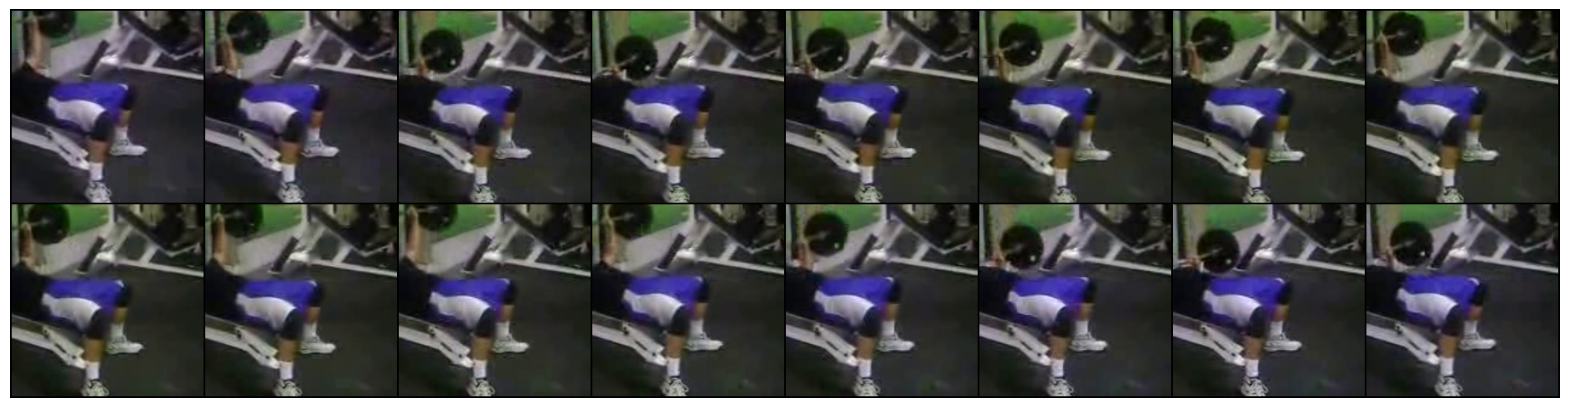

In [4]:
ret_frames=ret_imgs.view(len(images), 3, *ret_imgs.shape[-2:])
fig, ax=plt.subplots(figsize=(20,10))
ax.imshow(make_grid(ret_frames).permute(1,2,0))
ax.axis('off')